# DecPyMC-9 : Du risque à la prime — prime pure, chargement, prime commerciale

**Navigation** : [<< DecPyMC-2 (utilité de l'argent, prime de risque)](DecPyMC-2-Utility-Money.ipynb) | [Index PyMC](README.md) | [Index DecisionTheory](../README.md)

**Filiation** : volet T1 de la jambe actuarielle de la Théorie de la Décision (EPIC #12904), en miroir de la jambe assurance de la Théorie des Jeux (GT-17a/17b : antisélection et screening vus du côté marché).

**Objectif** : répondre à une question concrète d'actuariat — *comment passer d'une distribution de sinistres à un tarif commercialement justifiable ?* Nous distinguons trois régimes que la théorie de la décision bayésienne classique mélange : le régime **fréquentiste** (paramètres connus, prime pure déterministe), le régime **bayésien** (incertitude sur les paramètres, la prime pure devient une distribution) et le régime **commercial** (le chargement transforme une estimation technique en prix de marché).

**Prérequis** : [DecPyMC-2](DecPyMC-2-Utility-Money.ipynb) (utilité, équivalent certain, prime de risque) et des bases de PyMC. Aucun prérequis en actuariat : chaque terme du métier est défini à sa première apparition.

**Durée estimée** : ~45 min.

***
## 1. La charnière : deux primes qui n'ont pas le même objet

Le notebook [DecPyMC-2](DecPyMC-2-Utility-Money.ipynb) définissait la **prime de risque décisionnelle** d'un individu face à une loterie :

$$\text{Prime}_{risque} = \mathbb{E}[gain] - CE$$

où $CE$ est l'équivalent certain — le gain garanti qui laisse l'individu indifférent. Cette prime mesure ce qu'un individu **accepterait de payer pour éviter** le risque. L'assureur se tient de l'autre côté de la table : il **achète** le risque. Son point de départ n'est pas un gain espéré mais un **coût espéré** — et son tarif ne peut pas se déduire de la prime de risque de l'assuré seul.

Rappelons d'abord le mécanisme de DecPyMC-2 sur un exemple chiffré :

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# Rappel DecPyMC-2 : prime de risque décisionnelle (CRRA) d'un assuré
rho = 0.5                      # aversion relative au risque
W0 = 100_000.0                 # richesse initiale (EUR)
gains = np.array([-2_000.0, +1_000.0, +4_000.0])
probas = np.array([0.2, 0.5, 0.3])

def utilite_crra(w, rho):
    return w ** (1 - rho) / (1 - rho)

E_gain = float(probas @ gains)
E_U = float(probas @ utilite_crra(W0 + gains, rho))
CE_gain = ((1 - rho) * E_U) ** (1 / (1 - rho)) - W0   # équivalent certain, exprimé en gain
prime_risque = E_gain - CE_gain

print(f"E[gain]                    = {E_gain:9.1f} EUR")
print(f"Équivalent certain (gain)  = {CE_gain:9.1f} EUR")
print(f"Prime de risque            = {prime_risque:9.1f} EUR")

g++ not available, if using conda: `conda install gxx`


E[gain]                    =    1300.0 EUR
Équivalent certain (gain)  =    1289.1 EUR
Prime de risque            =      10.9 EUR


### Interprétation

Avec $\rho = 0{,}5$, l'assuré accepterait de renoncer à une partie de l'espérance pour garantir son gain : c'est le **prix subjectif du risque** pour un individu seul, avec ses propres paramètres. Un assureur ne peut pas tarifer en additionnant ces primes individuelles : il porte des **milliers** de risques simultanément, les grands nombres se compensent, et son problème n'est pas l'aversion au risque mais l'**estimation**. La question actuarielle est donc tout autre : quel est le coût *attendu* du risque transféré, et quelle incertitude pèse sur ce coût ? C'est l'objet du régime fréquentiste de la section 2.

***
## 2. Le modèle fréquence × sévérité (régime 1 : paramètres connus)

Le modèle canonique du coût d'assurance par assuré et par an :

- **Fréquence** : le nombre de sinistres $N$ par an suit une loi de Poisson $N \sim \mathcal{P}(\lambda)$ ;
- **Sévérité** : le coût $S$ d'un sinistre suit une loi log-normale $S \sim \mathcal{LN}(\mu, \sigma)$ (coûts positifs, queue lourde à droite — quelques sinistres énormes) ;
- **Coût total annuel** : $Y = \sum_{i=1}^{N} S_i$ (loi composée).

La **prime pure** est l'espérance du coût :

$$\pi = \mathbb{E}[Y] = \mathbb{E}[N] \cdot \mathbb{E}[S] = \lambda \, e^{\mu + \sigma^2/2}$$

Deux portefeuilles aux profils opposés nous serviront de fil rouge :

In [2]:
# Deux portefeuilles aux profils opposés
PORTEFEUILLES = {
    # auto tous risques : sinistres FRÉQUENTS et LÉGERS
    "A_auto":   dict(lam=0.80, mediane_S=1_200.0, sigma_log=0.9),
    # responsabilité civile médicale : sinistres RARES et LOURDS
    "B_rc_med": dict(lam=0.05, mediane_S=90_000.0, sigma_log=1.1),
}

print(f"{'Portefeuille':<12} {'lambda/an':>9} {'médiane S':>10} {'E[S] (EUR)':>12} {'pi (EUR/an)':>12}")
for nom, p in PORTEFEUILLES.items():
    p["mu_log"] = np.log(p["mediane_S"])
    p["E_S"] = np.exp(p["mu_log"] + p["sigma_log"]**2 / 2)
    p["pi"] = p["lam"] * p["E_S"]
    print(f"{nom:<12} {p['lam']:>9.2f} {p['mediane_S']:>10.0f} {p['E_S']:>12.0f} {p['pi']:>12.0f}")

Portefeuille lambda/an  médiane S   E[S] (EUR)  pi (EUR/an)
A_auto            0.80       1200         1799         1439
B_rc_med          0.05      90000       164813         8241


### Interprétation

La prime pure d'auto (~1 440 EUR/an) et celle de RC médicale (~8 240 EUR/an) sont du même ordre de grandeur par des chemins *totalement* opposés : 0,8 sinistre/an à ~1 800 EUR de coût moyen, contre 0,05 sinistre/an à ~165 000 EUR. L'espérance seule ne dit rien de la **forme** du risque — et c'est la forme qui va commander le chargement. Simulons la loi composée $Y$ pour voir ce que l'assureur encaisse réellement année après année :

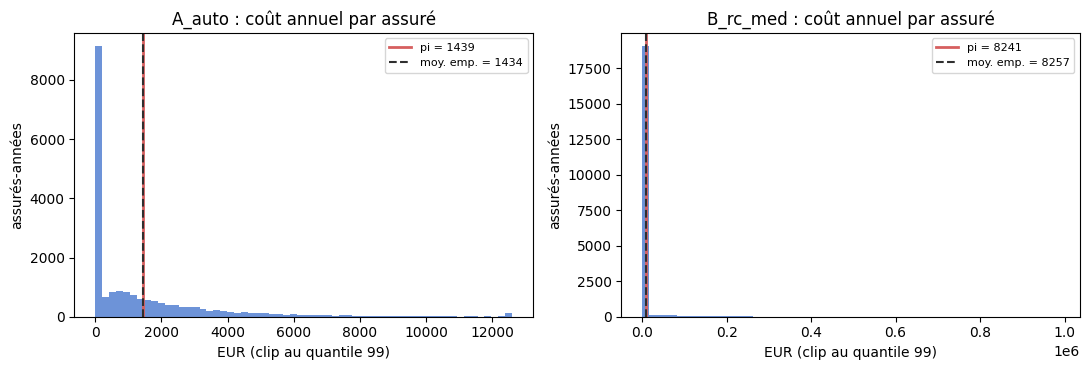

A_auto     P(Y>pi) = 0.322 | Q95(Y) =      5951 | Q99.5(Y) =      13191 | pi = 1439
B_rc_med   P(Y>pi) = 0.050 | Q95(Y) =      7866 | Q99.5(Y) =     362316 | pi = 8241


In [3]:
# Simulation Monte Carlo de la loi composée Y (coût annuel par assuré)
rng = np.random.default_rng(20260825)
N_ASSURES, N_ANNEES = 2_000, 10

def cout_par_assure_annee(p, n, rng):
    N = rng.poisson(p["lam"], size=n)
    total = np.zeros(n)
    for i in np.nonzero(N)[0]:
        total[i] = rng.lognormal(p["mu_log"], p["sigma_log"], size=N[i]).sum()
    return total

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (nom, p) in zip(axes, PORTEFEUILLES.items()):
    Y = np.concatenate([cout_par_assure_annee(p, N_ASSURES, rng) for _ in range(N_ANNEES)])
    p["Y_sim"] = Y
    borne = np.quantile(Y[Y > 0], 0.99)
    ax.hist(np.clip(Y, 0, borne), bins=60, color="#4878CF", alpha=0.8)
    ax.axvline(p["pi"], color="#D65F5F", lw=2, label=f"pi = {p['pi']:.0f}")
    ax.axvline(Y.mean(), color="#2F2F2F", lw=1.5, ls="--", label=f"moy. emp. = {Y.mean():.0f}")
    ax.set_title(f"{nom} : coût annuel par assuré")
    ax.set_xlabel("EUR (clip au quantile 99)")
    ax.set_ylabel("assurés-années")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for nom, p in PORTEFEUILLES.items():
    Y = p["Y_sim"]
    print(f"{nom:<10} P(Y>pi) = {(Y > p['pi']).mean():.3f} | "
          f"Q95(Y) = {np.quantile(Y, 0.95):>9.0f} | Q99.5(Y) = {np.quantile(Y, 0.995):>10.0f} | pi = {p['pi']:.0f}")

### Interprétation

Deux faits structurants. (1) La moyenne empirique confirme la formule $\pi = \lambda\,\mathbb{E}[S]$ — le régime fréquentiste tient ses promesses quand les paramètres sont connus. (2) Mais $Y$ est **asymétrique à droite** : par assuré, la probabilité de dépasser la prime pure dépend très fortement du portefeuille — `P(Y > π) ≈ 0,322` pour A_auto (auto tous risques, un peu moins d'un tiers des années) et seulement `P(Y > π) ≈ 0,050` pour B_rc_med (RC médicale, une année sur vingt) ; quant au quantile 99,5, il monte à plusieurs fois $\pi$ dans les deux cas. Agrégé sur un grand portefeuille, la loi des grands nombres lisse une partie de cette variance — mais pas l'incertitude sur les paramètres eux-mêmes, qui est **systématique** : si $\lambda$ est sous-estimé, tous les assurés du portefeuille sont sous-tarifés *ensemble*. C'est la faille que le régime bayésien mesure.

### Exercice 1 : prime pure et prime commerciale d'un portefeuille habitation

Un assureur démarre sur le marché habitation : fréquence $\lambda = 0{,}15$ sinistre/an, sévérité médiane 2 800 EUR, $\sigma = 1{,}0$ en log. Recalculer $\mathbb{E}[S]$, la prime pure $\pi$, puis la prime commerciale $P = \pi / (1 - 0{,}10)$ (décomposition de chargement de la section 4).

**Étapes** : (1) $\mu = \ln(2\,800)$ ; (2) $\mathbb{E}[S] = e^{\mu + \sigma^2/2}$ ; (3) $\pi = \lambda \cdot \mathbb{E}[S]$ ; (4) $P = \pi / 0{,}9$.

In [4]:
# Exercice 1 : à compléter
lam_hab = 0.15
mediane_hab = 2_800.0
sigma_hab = 1.0

E_S_hab = None    # TODO étudiant : appliquer la formule E[S] = exp(mu + sigma^2 / 2)
pi_hab = None     # TODO étudiant : prime pure = lam * E_S
P_hab = None      # TODO étudiant : prime commerciale = pi / (1 - 0.10)

print("Exercice 1 à compléter :")
print(f"  E_S_hab = {E_S_hab}")
print(f"  pi_hab  = {pi_hab}")
print(f"  P_hab   = {P_hab}")

Exercice 1 à compléter :
  E_S_hab = None
  pi_hab  = None
  P_hab   = None


***
## 3. Régime bayésien : les paramètres ne sont pas connus

Le régime précédent suppose $\lambda, \mu, \sigma$ **connus**. En pratique un assureur ne les connaît jamais : il les estime sur un historique. Prenons deux versions du même portefeuille RC médicale :

- **B_jeune** : un jeune cabinet mutualisé, 60 médecins assurés depuis 3 ans — l'expérience tient à une poignée de sinistres ;
- **B_mature** : la même structure après 30 ans — un historique dix fois plus long.

Générons des historiques synthétiques (paramètres vrais identiques, seule la profondeur d'historique change) :

In [5]:
# Historiques synthétiques : même vérité (lam=0.05, S~LN(ln 90 000, 1.1)), profondeurs différentes
rng_h = np.random.default_rng(7)
N_ASSURES_B = 60

obs_N_jeune = rng_h.poisson(0.05 * N_ASSURES_B, size=3)     # 3 années de comptages annuels
obs_N_mature = rng_h.poisson(0.05 * N_ASSURES_B, size=30)    # 30 années

nb_sinis_jeune = int(obs_N_jeune.sum())
nb_sinis_mature = int(obs_N_mature.sum())
sev_obs_jeune = rng_h.lognormal(np.log(90_000.0), 1.1, size=nb_sinis_jeune)
sev_obs_mature = rng_h.lognormal(np.log(90_000.0), 1.1, size=nb_sinis_mature)

print(f"B_jeune  : 3 ans   | comptages annuels {obs_N_jeune.tolist()} | {nb_sinis_jeune} sinistres observés")
print(f"B_mature : 30 ans  | {nb_sinis_mature} sinistres observés au total")
print(f"Sévérités jeune  (EUR) : min {sev_obs_jeune.min():>9.0f} | médiane {np.median(sev_obs_jeune):>10.0f} | max {sev_obs_jeune.max():>10.0f}")
print(f"Sévérités mature (EUR) : min {sev_obs_mature.min():>9.0f} | médiane {np.median(sev_obs_mature):>10.0f} | max {sev_obs_mature.max():>10.0f}")

B_jeune  : 3 ans   | comptages annuels [4, 1, 4] | 9 sinistres observés
B_mature : 30 ans  | 87 sinistres observés au total
Sévérités jeune  (EUR) : min     13185 | médiane     103944 | max     439522
Sévérités mature (EUR) : min      8836 | médiane      75968 | max     711033


Le modèle de fréquence : une loi a priori Gamma sur $\lambda$ (ordre de grandeur honnête — moyenne 0,05/an, coefficient de variation ~70% : on sait juste que le risque est *rare*), corrigée par les comptages observés via une vraisemblance de Poisson sur le total annuel du cabinet ($\lambda \times 60$ assurés) :

In [6]:
# Modèle PyMC de fréquence — le même a priori pour les deux profondeurs d'historique
def modele_frequence(obs_N):
    with pm.Model() as modele:
        lam = pm.Gamma("lam", alpha=2.0, beta=40.0)   # a priori : moyenne 0.05/an, CV ~ 70%
        N_annuel = pm.Poisson("N_annuel", mu=lam * N_ASSURES_B, observed=obs_N)
        idata = pm.sample(draws=2_000, tune=1_000, chains=2, random_seed=20260825,
                          progressbar=False, cores=2)
    return idata

idata_freq_jeune = modele_frequence(obs_N_jeune)
idata_freq_mature = modele_frequence(obs_N_mature)

resume = pd.concat([
    az.summary(idata_freq_jeune, var_names=["lam"]),
    az.summary(idata_freq_mature, var_names=["lam"]),
], keys=["B_jeune (3 ans)", "B_mature (30 ans)"])
print(resume.round(5))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [lam]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 4 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Multiprocess sampling (2 chains in 2 jobs)


NUTS: [lam]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 3 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


                         mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail  \
B_jeune (3 ans)   lam  0.0499  0.0147    0.029    0.075      1706      1844   
B_mature (30 ans) lam  0.0485  0.0051     0.04    0.057      1714      2213   

                      r_hat mcse_mean  mcse_sd  
B_jeune (3 ans)   lam  1.00   0.00034  0.00028  
B_mature (30 ans) lam  1.00   0.00012  8.8e-05  


### Interprétation

Le même a priori, deux profondeurs de données : le posterior de $\lambda$ pour le cabinet mature est nettement plus resserré que pour le jeune cabinet (les intervalles de crédibilité ETI 89% se lisent directement dans la sortie). Avec 3 ans de comptages, l'incertitude sur la fréquence reste de l'ordre de plusieurs dizaines de pourcents — et ce n'est pas du bruit d'échantillonnage qui se moyenne sur le portefeuille (il est déjà dans la Poisson) : c'est de l'**incertitude systématique**. C'est précisément ce que la crédibilité actuarielle (volet T3 de l'EPIC #12904) arbitre entre expérience individuelle et expérience collective.

Faisons de même pour la sévérité :

In [7]:
# Modèle PyMC de sévérité — a priori d'ordre de grandeur, corrigés par les sinistres observés
def modele_severite(sev_obs):
    with pm.Model() as modele:
        mu = pm.Normal("mu", mu=np.log(50_000.0), sigma=1.0)   # dizaines de milliers d'EUR
        sigma = pm.HalfNormal("sigma", sigma=1.0)
        S_obs = pm.LogNormal("S_obs", mu=mu, sigma=sigma, observed=sev_obs)
        idata = pm.sample(draws=2_000, tune=1_000, chains=2, random_seed=20260825,
                          progressbar=False, cores=2)
    return idata

idata_sev_jeune = modele_severite(sev_obs_jeune)
idata_sev_mature = modele_severite(sev_obs_mature)

diag = pd.concat([
    az.summary(idata_sev_jeune, var_names=["mu", "sigma"]),
    az.summary(idata_sev_mature, var_names=["mu", "sigma"]),
], keys=["jeune", "mature"])
print(diag.round(3))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu, sigma]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 3 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu, sigma]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 4 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


                mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
jeune  mu      11.34    0.4       11       12      3277      2571  1.00   
       sigma     1.3  0.289     0.92      1.8      3078      2422  1.00   
mature mu     11.271  0.103       11       11      4020      2934  1.00   
       sigma   1.003  0.075     0.89      1.1      3831      2698  1.00   

             mcse_mean mcse_sd  
jeune  mu       0.0071  0.0056  
       sigma    0.0053  0.0047  
mature mu       0.0016  0.0012  
       sigma    0.0012  0.0009  


### Interprétation

Les diagnostics ArviZ sont propres (ESS élevé, $\hat{r} \approx 1{,}00$) : les deux chaînes convergent, les posteriors sont exploitables. La sévérité du jeune cabinet (une poignée de sinistres) garde une incertitude marquée sur $\sigma$ — le paramètre qui pilote la queue de distribution, donc les sinistres extrêmes. Il ne reste qu'à propager ces deux incertitudes vers la quantité qui intéresse l'assureur : la prime pure $\pi = \lambda \, e^{\mu + \sigma^2/2}$.

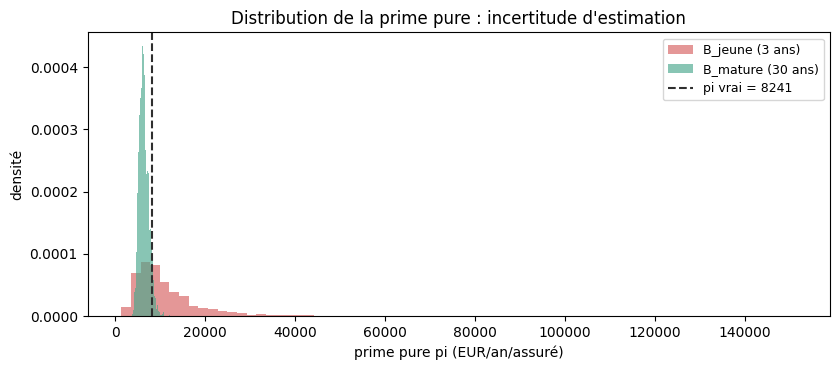

B_jeune    moyenne   12315 | Q5    3810 | Q50    9221 | Q95   29420 | CV = 0.90
B_mature   moyenne    6363 | Q5    4826 | Q50    6257 | Q95    8304 | CV = 0.17


In [8]:
# Propagation des posteriors vers la prime pure : pi devient une DISTRIBUTION
def echantillons_pi(idata_freq, idata_sev, n=4_000):
    lam = idata_freq.posterior["lam"].values.flatten()[:n]
    mu = idata_sev.posterior["mu"].values.flatten()[:n]
    sigma = idata_sev.posterior["sigma"].values.flatten()[:n]
    return lam * np.exp(mu + sigma**2 / 2)

pi_jeune = echantillons_pi(idata_freq_jeune, idata_sev_jeune)
pi_mature = echantillons_pi(idata_freq_mature, idata_sev_mature)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.hist(pi_jeune, bins=70, alpha=0.65, density=True, color="#D65F5F", label="B_jeune (3 ans)")
ax.hist(pi_mature, bins=70, alpha=0.65, density=True, color="#48A78C", label="B_mature (30 ans)")
ax.axvline(PORTEFEUILLES["B_rc_med"]["pi"], color="#2F2F2F", lw=1.5, ls="--",
           label=f"pi vrai = {PORTEFEUILLES['B_rc_med']['pi']:.0f}")
ax.set_xlabel("prime pure pi (EUR/an/assuré)")
ax.set_ylabel("densité")
ax.set_title("Distribution de la prime pure : incertitude d'estimation")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

for nom, pi_s in [("B_jeune", pi_jeune), ("B_mature", pi_mature)]:
    q = np.quantile(pi_s, [0.05, 0.50, 0.95])
    cv = pi_s.std() / pi_s.mean()
    print(f"{nom:<10} moyenne {pi_s.mean():>7.0f} | Q5 {q[0]:>7.0f} | Q50 {q[1]:>7.0f} | "
          f"Q95 {q[2]:>7.0f} | CV = {cv:.2f}")

### Interprétation

Le régime bayésien transforme la prime pure en **distribution** : le cabinet mature la connaît à quelques dizaines de pourcents près, le jeune cabinet nettement moins bien (lisez les CV dans la sortie). Autrement dit, pour le jeune cabinet, tarifer à la moyenne c'est accepter une chance sur vingt d'être sous-tarifé de la moitié de la prime. Et la distribution raconte une seconde histoire : le posterior mature est bien centré sur la valeur vraie (pointillé), celui du jeune cabinet est à la fois plus large et décalé ici vers le haut — neuf sinistres observés dont la médiane (104 k EUR) dépasse la médiane vraie (90 k) suffisent à décaler l'estimation. L'incertitude d'un petit historique n'est pas que de la dispersion, c'est aussi un risque de biais d'échantillonnage : tarifer sur trois ans d'expérience, c'est accepter les deux. La question devient commerciale : **comment fixer le chargement quand la volatilité de $\pi$ est grande ?**

***
## 4. Le chargement : décomposition et prime commerciale

La **prime commerciale** transforme l'estimation technique en prix. Convention multiplicative standard :

$$P = \frac{\pi}{1 - c}, \qquad c = c_{frais} + c_{provision} + c_{marge}$$

où le chargement $c$ se décompose en **frais** (acquisition, gestion : ~5%), **provision pour risques** (couvrir la volatilité résiduelle : ~3%) et **marge** (~2%). Attention au piège de la convention : dans la forme multiplicative, le chargement s'exprime **en pourcentage de la prime** (le prix final), pas de la prime pure — 10% de décomposition donnent +11,1% sur $\pi$.

In [9]:
# Décomposition du chargement et prime commerciale des deux portefeuilles
c_frais, c_provision, c_marge = 0.05, 0.03, 0.02
c_total = c_frais + c_provision + c_marge

lignes = []
for nom, p in PORTEFEUILLES.items():
    P_mult = p["pi"] / (1 - c_total)      # convention multiplicative (en % de la prime)
    P_add = p["pi"] * (1 + c_total)       # convention additive (en % de la prime pure)
    lignes.append(dict(portefeuille=nom, pi=p["pi"], P_mult=P_mult, P_add=P_add,
                       ecart_conventions=P_mult - P_add))
tbl = pd.DataFrame(lignes).round(1)
print(tbl.to_string(index=False))

portefeuille     pi  P_mult  P_add  ecart_conventions
      A_auto 1439.3  1599.3 1583.3               16.0
    B_rc_med 8240.6  9156.3 9064.7               91.6


### Interprétation

L'écart entre les deux conventions (~16 EUR par contrat A_auto, ~91 EUR par contrat B_rc_med) paraît anecdotique ; sur 100 000 contrats il représente plus d'un million et demi d'euros par an. La convention n'est jamais neutre et doit être contractuellement fixée. Mais la vraie question est celle du **niveau** de $c$ : la décomposition 5/3/2 ci-dessus suppose un portefeuille à incertitude maîtrisée. Que se passe-t-il quand l'incertitude d'estimation est celle du jeune cabinet ?

In [10]:
# Chargement de sécurité nécessaire pour couvrir un quantile de pi
quantiles = [0.50, 0.75, 0.95, 0.99]
lignes = []
for nom, pi_s in [("B_jeune", pi_jeune), ("B_mature", pi_mature)]:
    base = pi_s.mean()
    for q in quantiles:
        c_safe = np.quantile(pi_s, q) / base - 1     # chargement additif couvrant le quantile q
        lignes.append(dict(portefeuille=nom, quantile=f"Q{int(q*100)}",
                           c_securite=c_safe, P_associe=base * (1 + c_safe)))
tbl = pd.DataFrame(lignes)
tbl["c_securite"] = (tbl["c_securite"] * 100).round(1)
tbl["P_associe"] = tbl["P_associe"].round(0)
print(tbl.to_string(index=False))

portefeuille quantile  c_securite  P_associe
     B_jeune      Q50       -25.1     9221.0
     B_jeune      Q75        15.8    14266.0
     B_jeune      Q95       138.9    29420.0
     B_jeune      Q99       383.3    59515.0
    B_mature      Q50        -1.7     6257.0
    B_mature      Q75        10.3     7020.0
    B_mature      Q95        30.5     8304.0
    B_mature      Q99        47.2     9368.0


### Interprétation

Le chargement de sécurité ne coûte pas la même chose selon le portefeuille : pour intégrer le risque d'estimation (incertitude sur les paramètres $\lambda, \mu, \sigma$ reflétée dans la largeur du posterior de $\pi$), le cabinet **mature** a besoin d'un chargement de sécurité modéré, le **jeune** cabinet de nettement plus — son ignorance est plus chère (comparez les lignes Q95 dans la sortie). Le message central de ce notebook : **le chargement n'est pas qu'une marge**. Il couvre simultanément (i) l'incertitude d'*estimation* — le régime bayésien de la section 3 —, (ii) la provision pour la volatilité résiduelle, (iii) les frais, (iv) la marge. C'est aussi par cette porte qu'entre la question de la ruine (quel capital immobiliser, volet T4 de l'EPIC #12904) : un tarif fixé au Q95 du posterior de $\pi$ laisse 5% de probabilité postérieure que la prime pure sous-jacente $\pi$ dépasse ce tarif (incertitude d'*estimation*, intra-posterior) — ce qui n'est PAS la même chose que 5% des années en perte technique : la probabilité annuelle que le coût réel $Y$ dépasse la prime tarifiée relève de l'incertitude de *processus* (variabilité intra-annuelle des $S$ composée avec le processus de fréquence $N$), et sa propagation complète demanderait de convoluer cette variabilité intra-annuelle avec l'incertitude inter-annuelle des paramètres, ce qui relève de la ruine (volet T4 de l'EPIC #12904).

### Exercice 2 : chargement de sécurité du jeune cabinet au quantile 80

En reprenant `pi_jeune` (section 3), trouver le chargement $c^{\star}$ tel que la prime $P = \bar{\pi}\,(1 + c^{\star})$ couvre le quantile 80 de la distribution de $\pi$. Comparer au chargement commercial standard de 10%.

**Étapes** : (1) calculer $\bar{\pi}$ = moyenne des échantillons ; (2) extraire le quantile 80 ; (3) résoudre $c^{\star} = Q_{80}/\bar{\pi} - 1$ ; (4) commenter l'écart avec le 10% standard.

In [11]:
# Exercice 2 : à compléter
pi_barre = None          # TODO étudiant : moyenne de pi_jeune
Q80 = None               # TODO étudiant : quantile 0.80 de pi_jeune
c_etoile = None          # TODO étudiant : c* = Q80 / pi_barre - 1

print("Exercice 2 à compléter :")
print(f"  pi_barre = {pi_barre}")
print(f"  Q80      = {Q80}")
print(f"  c*       = {c_etoile}")
print(f"  (chargement commercial standard = 0.10)")

Exercice 2 à compléter :
  pi_barre = None
  Q80      = None
  c*       = None
  (chargement commercial standard = 0.10)


***
## 5. Cas discriminants : décision tarifaire et antisélection

Assemblons le tableau de décision de l'actuaire : les deux portefeuilles du fil rouge plus le contraste jeune/mature, chacun avec sa prime pure, son incertitude et son chargement de sécurité nécessaire :

In [12]:
# Tableau de décision tarifaire
lignes = [
    dict(portefeuille="A_auto (régime fréquentiste)", pi=PORTEFEUILLES["A_auto"]["pi"],
         incertitude="paramètres connus (régime 1)", c_securite_Q95=np.nan),
    dict(portefeuille="B_rc_mature (régime bayésien)", pi=pi_mature.mean(),
         incertitude=f"CV = {pi_mature.std()/pi_mature.mean():.0%}",
         c_securite_Q95=np.quantile(pi_mature, 0.95) / pi_mature.mean() - 1),
    dict(portefeuille="B_rc_jeune (régime bayésien)", pi=pi_jeune.mean(),
         incertitude=f"CV = {pi_jeune.std()/pi_jeune.mean():.0%}",
         c_securite_Q95=np.quantile(pi_jeune, 0.95) / pi_jeune.mean() - 1),
]
tbl = pd.DataFrame(lignes)
tbl["P_commercial_10pc"] = tbl["pi"] / (1 - c_total)
tbl["pi"] = tbl["pi"].round(0)
tbl["P_commercial_10pc"] = tbl["P_commercial_10pc"].round(0)
tbl["c_securite_Q95"] = (tbl["c_securite_Q95"] * 100).round(0)
print(tbl.to_string(index=False))

                 portefeuille      pi                  incertitude  c_securite_Q95  P_commercial_10pc
 A_auto (régime fréquentiste)  1439.0 paramètres connus (régime 1)             NaN             1599.0
B_rc_mature (régime bayésien)  6363.0                     CV = 17%            30.0             7070.0
 B_rc_jeune (régime bayésien) 12315.0                     CV = 90%           139.0            13683.0


### Interprétation

La décision tarifaire diffère par régime : pour A_auto (paramètres stabilisés par le volume), le chargement commercial standard suffit ; pour le cabinet jeune, le chargement de sécurité nécessaire écrase la décomposition 5/3/2 — tarifer au standard, c'est subir un risque de sous-tarification systématique. Mais monter le chargement a un coût de marché : avant de conclure « gros chargement », il faut regarder la demande. C'est la **sensibilité au chargement** :

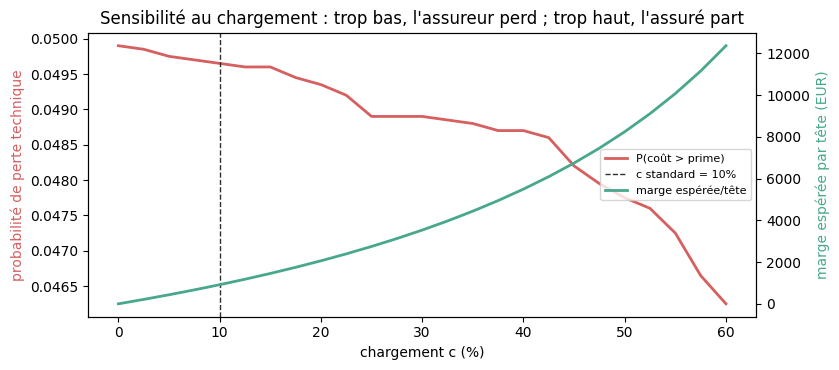

In [13]:
# Sensibilité : probabilité de perte technique et marge espérée en fonction du chargement
Y_mature = PORTEFEUILLES["B_rc_med"]["Y_sim"]     # coûts simulés par assuré-année (régime 1)
pi_B = PORTEFEUILLES["B_rc_med"]["pi"]

grille_c = np.linspace(0.0, 0.6, 25)
proba_perte = [(Y_mature > pi_B / (1 - c)).mean() for c in grille_c]
marge_par_tete = [pi_B / (1 - c) - pi_B for c in grille_c]

fig, ax1 = plt.subplots(figsize=(8.5, 3.8))
ax1.plot(grille_c * 100, proba_perte, color="#D65F5F", lw=2, label="P(coût > prime)")
ax1.set_xlabel("chargement c (%)")
ax1.set_ylabel("probabilité de perte technique", color="#D65F5F")
ax2 = ax1.twinx()
ax2.plot(grille_c * 100, marge_par_tete, color="#48A78C", lw=2, label="marge espérée/tête")
ax2.set_ylabel("marge espérée par tête (EUR)", color="#48A78C")
ax1.axvline(c_total * 100, color="#2F2F2F", ls="--", lw=1, label="c standard = 10%")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="center right", fontsize=8)
plt.title("Sensibilité au chargement : trop bas, l'assureur perd ; trop haut, l'assuré part")
plt.tight_layout()
plt.show()

### Interprétation

Trop bas, le chargement laisse l'assureur en perte technique trop souvent ; plus il monte, plus la marge par tête croît — *dans un monde où l'assuré reste*. Mais l'assuré n'est pas captif : si le prix dépasse sa disposition à payer, il résilie, et ce sont les **moins risqués** qui partent les premiers (ils trouvent mieux ailleurs, et ils y ont le plus intérêt). Simulons cette spirale d'antisélection, miroir exact du marché des citrons de GT-17a :

In [14]:
# Spirale d'antisélection : deux types cachés, tarification au mélange
E_S_B = PORTEFEUILLES["B_rc_med"]["E_S"]
lam_bon, lam_mauvais = 0.03, 0.09
part_bons = 0.50
surprime_toleree = 0.25          # un bon risque accepte au plus 25% au-dessus de SA prime pure
P_max_bon = lam_bon * E_S_B * (1 + surprime_toleree)

tours = []
for tour in range(6):
    lam_mixte = part_bons * lam_bon + (1 - part_bons) * lam_mauvais
    pi_mixte = lam_mixte * E_S_B
    P = pi_mixte / (1 - c_total)
    tours.append(dict(tour=tour, part_bons=round(part_bons, 3), pi_mixte=round(pi_mixte),
                      P=round(P), bons_restants=(P <= P_max_bon)))
    if P <= P_max_bon:
        break                    # équilibre : les bons restent
    part_bons *= 0.55            # campagne de résiliation : 45% des bons partent chez le concurrent

print(f"Disposition à payer d'un bon risque : {P_max_bon:.0f} EUR/an")
print(pd.DataFrame(tours).to_string(index=False))

Disposition à payer d'un bon risque : 6180 EUR/an
 tour  part_bons  pi_mixte     P  bons_restants
    0      0.500      9889 10988          False
    1      0.275     12114 13460          False
    2      0.151     13337 14819          False
    3      0.083     14011 15567          False
    4      0.046     14381 15979          False
    5      0.025     14584 16205          False


### Interprétation

Le prix au mélange dépasse immédiatement la disposition à payer des bons risques : ils partent, le portefeuille restant se dégrade, la prime pure du mélange monte, et le prix suit — jusqu'à un pool composé presque uniquement de mauvais risques, tarifé environ trois fois la prime pure initiale des bons. **Tarifer au mélange sans information, c'est organiser la sélection adverse contre soi-même** : c'est exactement le diagnostic d'Akerlof (GT-17a), relu du côté assureur. La réponse du marché — des gammes de contrats qui séparent les types (franchise contre prime réduite, bonus-malus) — est le screening de Rothschild-Stiglitz et Wilson traité par GT-17b. La théorie de la décision fournit le *prix* ; la théorie des jeux explique pourquoi un seul prix ne suffit pas.

### Exercice 3 : décision tarifaire sur trois profils opposés

Trois portefeuilles vous sont confiés : (1) A_auto, paramètres connus, grand volume ; (2) B_rc_mature, 30 ans d'historique ; (3) B_rc_jeune, 3 ans d'historique. Pour chacun, indiquer le chargement de sécurité approprié et la stratégie (tarifer au standard / sur-tarifer provisoirement / refuser et mutualiser plus longtemps).

**Étapes** : (1) reprendre le tableau de décision ; (2) comparer CV et chargement de sécurité Q95 ; (3) proposer une décision argumentée par portefeuille.

In [15]:
# Exercice 3 : à compléter
decision_A = None        # TODO étudiant : chargement + stratégie pour A_auto
decision_Bm = None       # TODO étudiant : idem pour B_rc_mature
decision_Bj = None       # TODO étudiant : idem pour B_rc_jeune

print("Exercice 3 à compléter :")
for nom, d in [("A_auto", decision_A), ("B_rc_mature", decision_Bm), ("B_rc_jeune", decision_Bj)]:
    print(f"  {nom:<12} : {d}")

Exercice 3 à compléter :
  A_auto       : None
  B_rc_mature  : None
  B_rc_jeune   : None


***
## Conclusion

Ce notebook a défait l'amalgame entre trois primes qui n'ont pas le même objet : la **prime de risque** décisionnelle (le prix subjectif du risque pour un individu), la **prime pure** $\pi = \lambda\,\mathbb{E}[S]$ (le coût attendu du risque transféré) et la **prime commerciale** $P = \pi/(1-c)$ (un prix de marché). Le chargement $c$ n'y est pas une marge parmi d'autres : il couvre l'incertitude d'estimation — le régime bayésien montre que $\pi$ est une distribution dont la largeur dépend de la profondeur d'historique —, la provision pour risques, les frais et la marge. Et la tarification ne se conclut jamais seule : monté trop haut, le prix déclenche la spirale d'antisélection qui vide le portefeuille de ses bons risques — le pont vers la jambe marché (GT-17a/17b) de la même EPIC actuarielle #12904.

**Prolongements dans l'EPIC #12904** : la crédibilité de Bühlmann-Straub (combien créditer l'expérience individuelle contre le collectif, volet T3), la ruine et le capital (quel quantile exiger, volet T4), la valeur de l'information en souscription (combien vaut un questionnaire qui sépare les types, volet T5).

## Références

- Kaas, Goovaerts, Dhaene & Denuit, *Modern Actuarial Risk Theory*, Springer (2008) — chapitres 1 et 5 (prime pure, chargements, lois composées)
- Bühlmann & Gisler, *A Course in Credibility Theory and its Applications*, Springer (2005)
- Akerlof (1970), *The Market for Lemons*, QJE 84(3) — lu côté marché dans GT-17a
- Rothschild & Stiglitz (1976), *Equilibrium in Competitive Insurance Markets*, QJE 90(4) — GT-17b
- EPIC #12904 — jambe actuarielle de la Théorie de la Décision (tranche T1 : ce notebook)